# LightGBM

The goal is to:
- train a baseline model
- evaluate performance using AUROC and AUPRC
- establish a reference for future feature comparisons (to also see which set of features wors best for this problem)


## Dataset A

In [1]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime

from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
train_df = pd.read_csv("../data/dataset_A_train.csv")
val_df = pd.read_csv("../data/dataset_A_val.csv")
test_df = pd.read_csv("../data/dataset_A_test.csv")

print(train_df.shape, val_df.shape, test_df.shape)

(5707, 225) (1446, 225) (1815, 225)


### Prep Features

We separate features and labels and remove non-feature columns such as peptide and HLA identifiers.

In [3]:
drop_cols = ["peptide", "HLA", "hla_sequence", "index"]

# split features and labels
X_train = train_df.drop(columns=drop_cols + ["Label"], errors="ignore")
y_train = train_df["Label"]

X_val = val_df.drop(columns=drop_cols + ["Label"], errors="ignore")
y_val = val_df["Label"]

X_test = test_df.drop(columns=drop_cols + ["Label"], errors="ignore")
y_test = test_df["Label"]

# 🔹 combine to ensure consistent encoding
X_all = pd.concat([X_train, X_val, X_test])

# find categorical (object) columns
cat_cols = X_all.select_dtypes(include=["object"]).columns

# convert to category + encode
for col in cat_cols:
    X_all[col] = X_all[col].astype("category")
    X_all[col] = X_all[col].cat.codes

# split back
X_train = X_all.iloc[:len(X_train)]
X_val   = X_all.iloc[len(X_train):len(X_train)+len(X_val)]
X_test  = X_all.iloc[len(X_train)+len(X_val):]

print(X_train.shape)

(5707, 220)


### Model Training

We train a LightGBM classifier using the training set and monitor performance on the validation set.

In [4]:
evals_result = {}

model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_metric="auc",
    callbacks=[lgb.record_evaluation(evals_result)]
)

[LightGBM] [Info] Number of positive: 2564, number of negative: 3143
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003557 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 35475
[LightGBM] [Info] Number of data points in the train set: 5707, number of used features: 220
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.449273 -> initscore=-0.203609
[LightGBM] [Info] Start training from score -0.203609
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


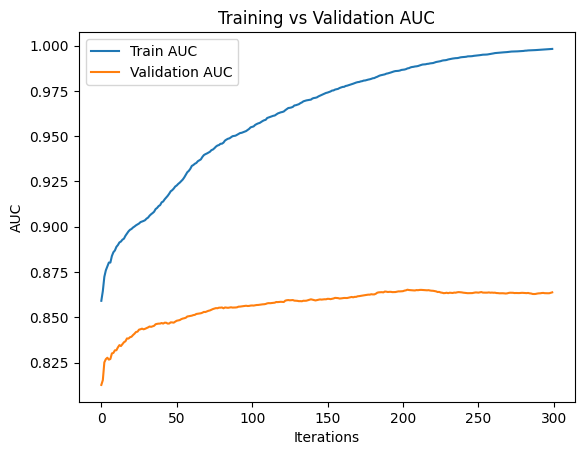

In [5]:
# Learning curve
train_auc = evals_result['training']['auc']
val_auc = evals_result['valid_1']['auc']

plt.plot(train_auc, label="Train AUC")
plt.plot(val_auc, label="Validation AUC")
plt.xlabel("Iterations")
plt.ylabel("AUC")
plt.legend()
plt.title("Training vs Validation AUC")
plt.show()

In [6]:
y_pred_proba_A = model.predict_proba(X_test)[:, 1]

auc_A = roc_auc_score(y_test, y_pred_proba_A)
auprc_A = average_precision_score(y_test, y_pred_proba_A)

print("Dataset A Test AUC:", auc_A)
print("Dataset A Test AUPRC:", auprc_A)

Dataset A Test AUC: 0.8705662858934291
Dataset A Test AUPRC: 0.8124957889609224


In [7]:
# basic feature importance
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

print(importance.head(20))

                       feature  importance
14            Peptide_BLOSUM10         145
8              Peptide_BLOSUM4         141
32                 Peptide_KF9         136
107  Peptide_instability_index         130
33                Peptide_KF10         123
53             Peptide_ProtFP7         116
18                  Peptide_F1         112
13             Peptide_BLOSUM9         108
55                 Peptide_SV1         107
54             Peptide_ProtFP8         107
4                  Peptide_AF5         103
26                 Peptide_KF3         101
94              Peptide_VSTPV4         101
100                 Peptide_Z4          98
35             Peptide_MSWHIM2          98
2                  Peptide_AF3          95
92              Peptide_VSTPV2          93
72              Peptide_SVGER6          93
30                 Peptide_KF7          92
12             Peptide_BLOSUM8          92


/home/hamdaalhosani/Downloads/yes/envs/benchmark/lib/python3.10/site-packages/shap/explainers/_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


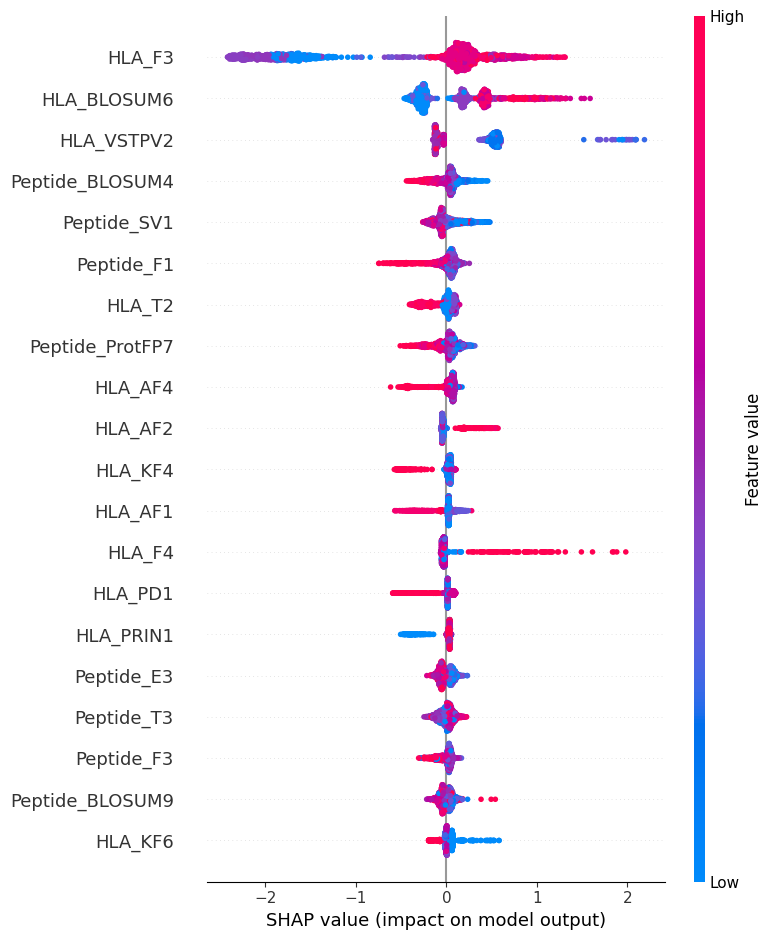

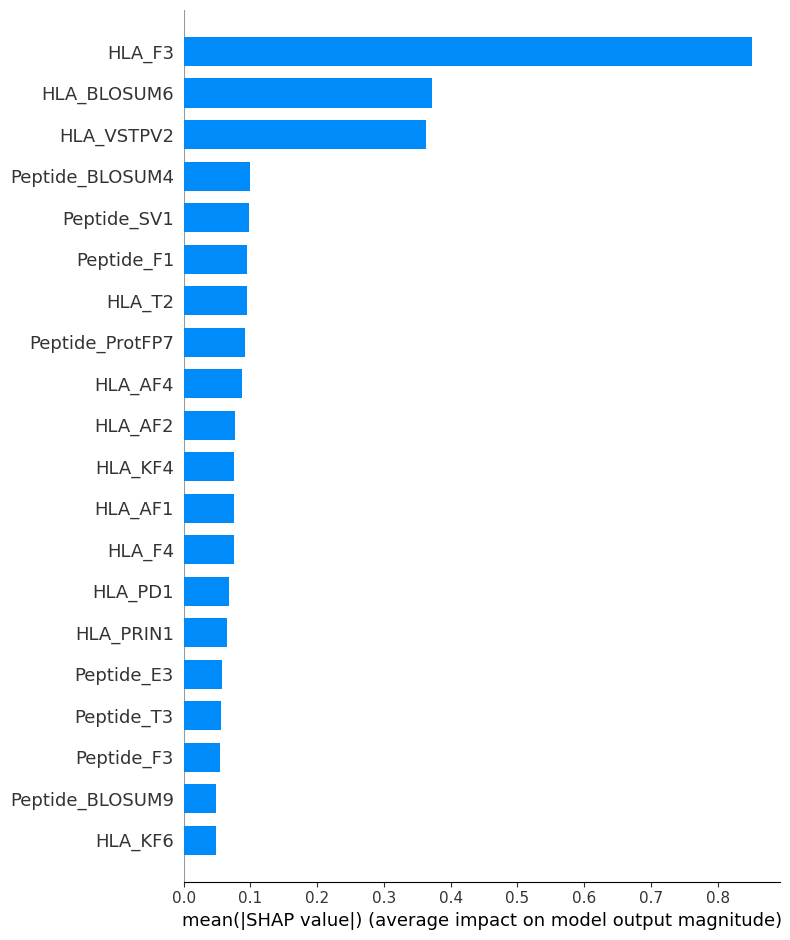

In [8]:
run_shap_analysis(model, X_test)

In [9]:
joblib.dump(
    model,
    "../models/lightgbm_datasetA_v1.pkl"
)

['../models/lightgbm_datasetA_v1.pkl']

## Dataset B

In [10]:
train_df_B = pd.read_csv("../data/dataset_B_train.csv")
val_df_B = pd.read_csv("../data/dataset_B_val.csv")
test_df_B = pd.read_csv("../data/dataset_B_test.csv")

print(train_df_B.shape, val_df_B.shape, test_df_B.shape)

(5707, 295) (1446, 295) (1815, 295)


### Prep Features

In [11]:
drop_cols = ["peptide", "HLA", "hla_sequence", "index"]

# split features and labels
X_train_B = train_df_B.drop(columns=drop_cols + ["Label"], errors="ignore")
y_train_B = train_df_B["Label"]

X_val_B = val_df_B.drop(columns=drop_cols + ["Label"], errors="ignore")
y_val_B = val_df_B["Label"]

X_test_B = test_df_B.drop(columns=drop_cols + ["Label"], errors="ignore")
y_test_B = test_df_B["Label"]

# combine to ensure consistent encoding
X_all_B = pd.concat([X_train_B, X_val_B, X_test_B])

# find categorical (object) columns
cat_cols_B = X_all_B.select_dtypes(include=["object"]).columns

# convert to category + encode
for col in cat_cols_B:
    X_all_B[col] = X_all_B[col].astype("category")
    X_all_B[col] = X_all_B[col].cat.codes

# split back
n_train = len(X_train_B)
n_val = len(X_val_B)

X_train_B = X_all_B.iloc[:n_train]
X_val_B   = X_all_B.iloc[n_train:n_train + n_val]
X_test_B  = X_all_B.iloc[n_train + n_val:]

print(X_train_B.shape, X_val_B.shape, X_test_B.shape)

(5707, 290) (1446, 290) (1815, 290)


### Model Training

In [12]:
evals_result_B = {}

model_B = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model_B.fit(
    X_train_B,
    y_train_B,
    eval_set=[(X_train_B, y_train_B), (X_val_B, y_val_B)],
    eval_metric="auc",
    callbacks=[lgb.record_evaluation(evals_result_B)]
)

[LightGBM] [Info] Number of positive: 2564, number of negative: 3143
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006475 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8963
[LightGBM] [Info] Number of data points in the train set: 5707, number of used features: 281
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.449273 -> initscore=-0.203609
[LightGBM] [Info] Start training from score -0.203609
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


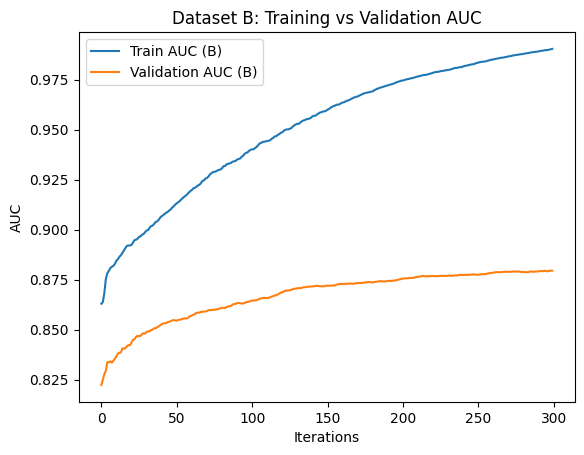

In [13]:
# Learning curve for Dataset B
train_auc_B = evals_result_B['training']['auc']
val_auc_B = evals_result_B['valid_1']['auc']

plt.plot(train_auc_B, label="Train AUC (B)")
plt.plot(val_auc_B, label="Validation AUC (B)")
plt.xlabel("Iterations")
plt.ylabel("AUC")
plt.legend()
plt.title("Dataset B: Training vs Validation AUC")
plt.show()

In [14]:
y_pred_proba_B = model_B.predict_proba(X_test_B)[:, 1]


auc_B = roc_auc_score(y_test_B, y_pred_proba_B)
auprc_B = average_precision_score(y_test_B, y_pred_proba_B)

print("Dataset B Test AUC:", auc_B)
print("Dataset B Test AUPRC:", auprc_B)

Dataset B Test AUC: 0.8863778864146248
Dataset B Test AUPRC: 0.8375397201892979


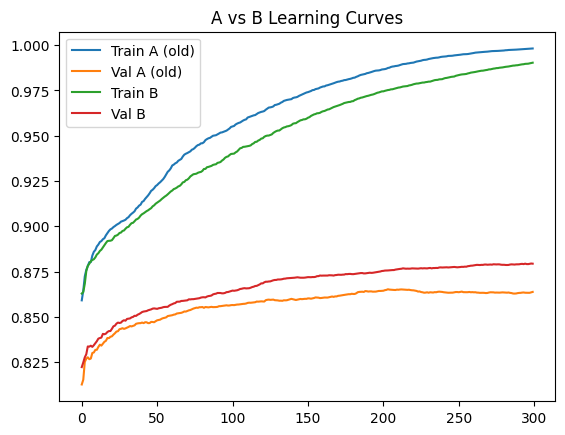

In [15]:
plt.plot(train_auc, label="Train A (old)")
plt.plot(val_auc, label="Val A (old)")

plt.plot(train_auc_B, label="Train B")
plt.plot(val_auc_B, label="Val B")

plt.legend()
plt.title("A vs B Learning Curves")
plt.show()

In [16]:
# basic feature importance for Dataset B
importance_B = pd.DataFrame({
    "feature": X_train_B.columns,
    "importance": model_B.feature_importances_
}).sort_values(by="importance", ascending=False)

print(importance_B.head(20))

               feature  importance
106  PeptidePos_p6_f17         181
16   PeptidePos_p1_f17         172
52   PeptidePos_p3_f17         161
124  PeptidePos_p7_f17         155
70   PeptidePos_p4_f17         153
48   PeptidePos_p3_f13         151
88   PeptidePos_p5_f17         150
102  PeptidePos_p6_f13         143
3     PeptidePos_p1_f4         137
142  PeptidePos_p8_f17         136
138  PeptidePos_p8_f13         135
160  PeptidePos_p9_f17         134
120  PeptidePos_p7_f13         133
66   PeptidePos_p4_f13         126
57    PeptidePos_p4_f4         122
39    PeptidePos_p3_f4         115
93    PeptidePos_p6_f4         114
34   PeptidePos_p2_f17         113
84   PeptidePos_p5_f13         111
156  PeptidePos_p9_f13         111


/home/hamdaalhosani/Downloads/yes/envs/benchmark/lib/python3.10/site-packages/shap/explainers/_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


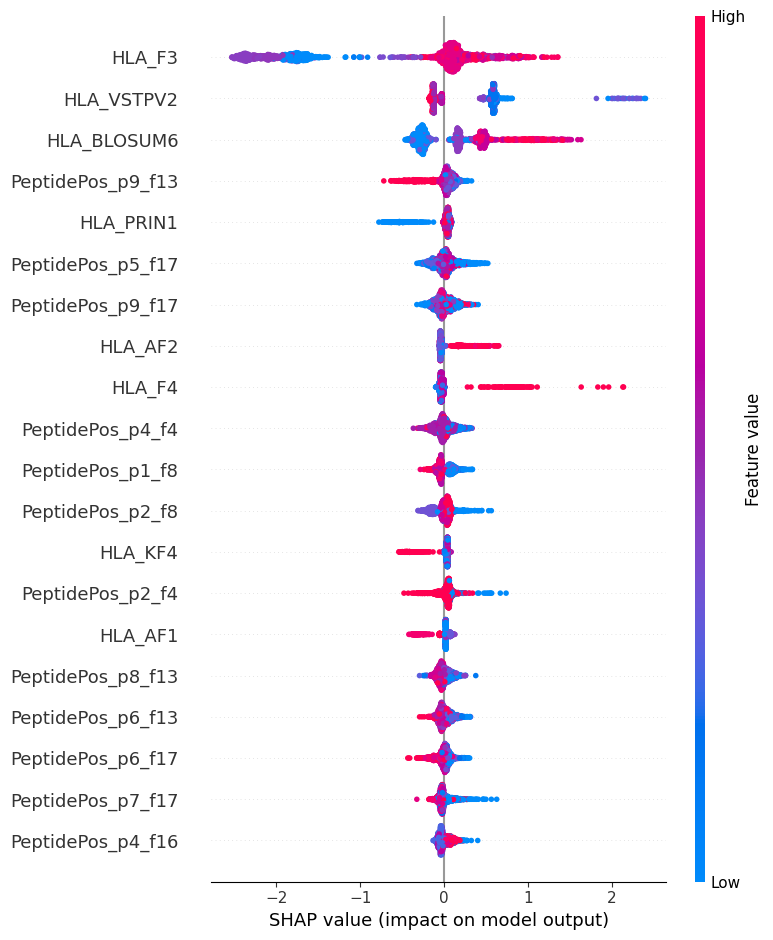

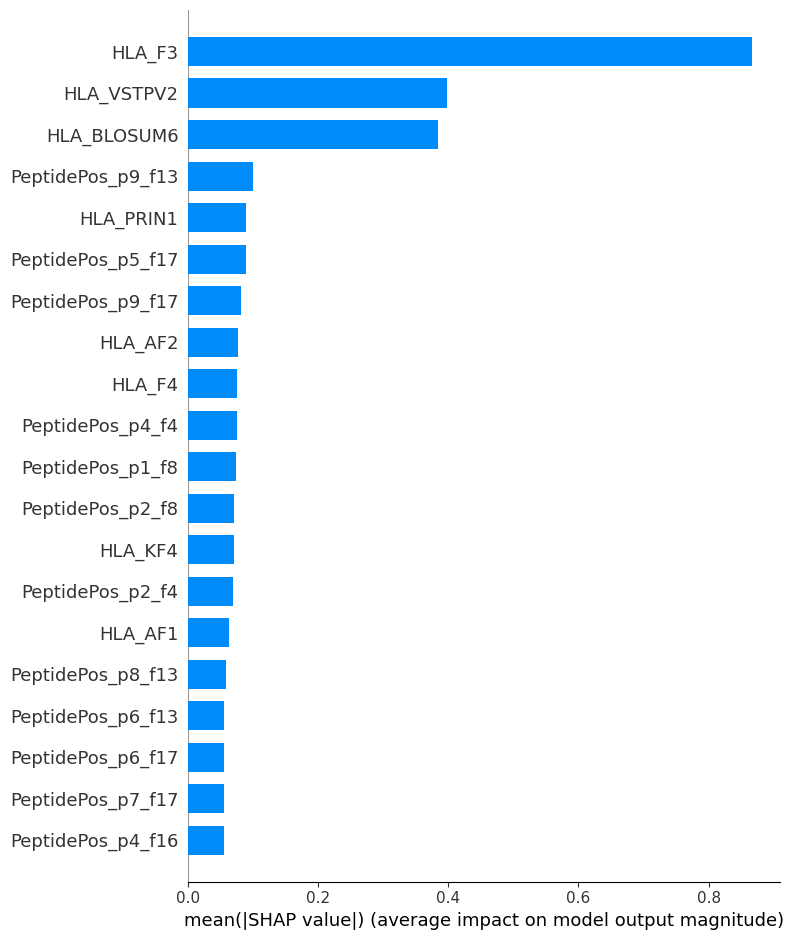

In [17]:
run_shap_analysis(model_B, X_test_B)

In [18]:
joblib.dump(
    model_B,
    "../models/lightgbm_datasetB_v1.pkl"
)

['../models/lightgbm_datasetB_v1.pkl']

## lightGBM on final selected dataset

In [2]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime
from utils import save_model

from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from scipy.stats import randint, uniform

OUTPUT_DIR = "../models"

/home/hamdaalhosani/Downloads/yes/envs/benchmark/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# load train / validation / test datasets
dataset_train = pd.read_csv("../data/dataset_train.csv")
dataset_val   = pd.read_csv("../data/dataset_val.csv")
dataset_test  = pd.read_csv("../data/dataset_test.csv")

#drop non-feature columns
DROP_COLS = ["index", "peptide", "HLA", "hla_sequence"]
TARGET_COL = "Label"

# Split labels
y_train = dataset_train[TARGET_COL].values
y_val   = dataset_val[TARGET_COL].values
y_test  = dataset_test[TARGET_COL].values

# Split features
X_train = dataset_train.drop(columns=[TARGET_COL] + [c for c in DROP_COLS if c in dataset_train.columns])
X_val   = dataset_val.drop(columns=[TARGET_COL] + [c for c in DROP_COLS if c in dataset_val.columns])
X_test  = dataset_test.drop(columns=[TARGET_COL] + [c for c in DROP_COLS if c in dataset_test.columns])

# Combine before one-hot encoding so all splits have matching columns
X_all = pd.concat(
    [X_train, X_val, X_test],
    axis=0,
    keys=["train", "val", "test"]
)

cat_cols = X_all.select_dtypes(include=["object", "category"]).columns.tolist()
print(f"Encoding categorical columns: {cat_cols}")

X_all = pd.get_dummies(X_all, columns=cat_cols)

# Split back
X_train = X_all.loc["train"]
X_val   = X_all.loc["val"]
X_test  = X_all.loc["test"]

print(f"Train: {X_train.shape}, Classes: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Val:   {X_val.shape}, Classes: {dict(zip(*np.unique(y_val, return_counts=True)))}")
print(f"Test:  {X_test.shape}, Classes: {dict(zip(*np.unique(y_test, return_counts=True)))}")

Encoding categorical columns: []
Train: (5707, 290), Classes: {np.int64(0): np.int64(3143), np.int64(1): np.int64(2564)}
Val:   (1446, 290), Classes: {np.int64(0): np.int64(778), np.int64(1): np.int64(668)}
Test:  (1815, 290), Classes: {np.int64(0): np.int64(991), np.int64(1): np.int64(824)}


In [4]:
model = LGBMClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained!!")

[LightGBM] [Info] Number of positive: 2564, number of negative: 3143
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004183 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8963
[LightGBM] [Info] Number of data points in the train set: 5707, number of used features: 281
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.449273 -> initscore=-0.203609
[LightGBM] [Info] Start training from score -0.203609
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [5]:
y_val_pred = model.predict(X_val)
y_val_prob = model.predict_proba(X_val)[:, 1]

val_accuracy = accuracy_score(y_val, y_val_pred)
val_auc = roc_auc_score(y_val, y_val_prob)
val_pr_auc = average_precision_score(y_val, y_val_prob)
val_mcc = matthews_corrcoef(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred)
val_recall = recall_score(y_val, y_val_pred)

print("Validation Results")
print(f"Accuracy:  {val_accuracy:.4f}")
print(f"ROC AUC:   {val_auc:.4f}")
print(f"PR AUC:    {val_pr_auc:.4f}")
print(f"MCC:       {val_mcc:.4f}")
print(f"F1:        {val_f1:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall:    {val_recall:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

Validation Results
Accuracy:  0.7828
ROC AUC:   0.8648
PR AUC:    0.8368
MCC:       0.5659
F1:        0.7718
Precision: 0.7500
Recall:    0.7949

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.77      0.79       778
           1       0.75      0.79      0.77       668

    accuracy                           0.78      1446
   macro avg       0.78      0.78      0.78      1446
weighted avg       0.78      0.78      0.78      1446



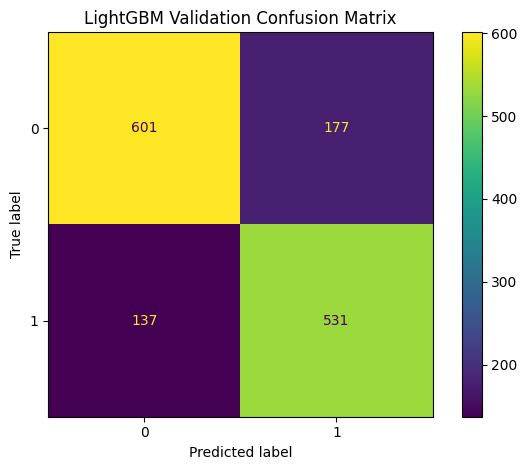

In [6]:
cm = confusion_matrix(y_val, y_val_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("LightGBM Validation Confusion Matrix")
plt.tight_layout()
plt.show()

In [7]:
MODEL_NAME = "lightgbm_v1"

metadata = {
    "dataset": "dataset_train / dataset_val / dataset_test",
    "features_shape": X_train.shape,
    "features": X_train.columns.tolist(),
    "val_accuracy": val_accuracy,
    "val_auc": val_auc,
    "val_pr_auc": val_pr_auc,
    "val_mcc": val_mcc,
    "val_f1": val_f1,
    "val_precision": val_precision,
    "val_recall": val_recall,
    "notes": "LightGBM baseline model"
}

model_path = save_model(
    model=model,
    output_dir=OUTPUT_DIR,
    model_name=MODEL_NAME,
    metadata=metadata
)

Saved model: ../models/lightgbm_v1.pkl
Saved metadata: ../models/lightgbm_v1_metadata.json


In [8]:
param_dist = {
    "n_estimators": randint(300, 1000),
    "max_depth": randint(3, 8),
    "learning_rate": uniform(0.01, 0.09),
    "num_leaves": randint(20, 150),
    "subsample": uniform(0.7, 0.3),
    "colsample_bytree": uniform(0.7, 0.3)
}


In [9]:
n_trials = 30
start_v = 2

results = []

for i in range(n_trials):
    version = f"v{start_v + i}"

    # sample parameters
    params = {k: v.rvs() for k, v in param_dist.items()}

    # add fixed params
    params.update({
        "random_state": 42
    })

    model = LGBMClassifier(**params)
    model.fit(X_train, y_train)

    # validation performance
    y_val_prob = model.predict_proba(X_val)[:, 1]
    y_val_pred = model.predict(X_val)

    val_auc = roc_auc_score(y_val, y_val_prob)
    val_mcc = matthews_corrcoef(y_val, y_val_pred)

    print(f"lightgbm_{version} | AUC: {val_auc:.4f} | MCC: {val_mcc:.4f}")

    # save model
    save_model(
        model=model,
        output_dir="../models",
        model_name=f"lightgbm_{version}",
        metadata={
            "dataset": "dataset_train / dataset_val / dataset_test",
            "features": X_train.columns.tolist(),
            "params": model.get_params(),
            "version": version,
            "val_auc": val_auc,
            "val_mcc": val_mcc,
            "notes": "LightGBM random search model"
        }
    )

    results.append({
        "version": version,
        "val_auc": val_auc,
        "val_mcc": val_mcc,
        **params
    })

# results dataframe
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("val_auc", ascending=False)

display(results_df)

best_row = results_df.iloc[0]
print("\nBest LightGBM random-search model:")
print(best_row)

[LightGBM] [Info] Number of positive: 2564, number of negative: 3143
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002453 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8963
[LightGBM] [Info] Number of data points in the train set: 5707, number of used features: 281
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.449273 -> initscore=-0.203609
[LightGBM] [Info] Start training from score -0.203609
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

,version,val_auc,val_mcc,n_estimators,max_depth,learning_rate,num_leaves,subsample,colsample_bytree,random_state
14,v16,0.883855,0.603249,812,7,0.080630,141,0.859610,0.918813,42
22,v24,0.882804,0.592615,698,6,0.030872,121,0.718603,0.715181,42
4,v6,0.882506,0.607958,362,7,0.066314,130,0.779002,0.886259,42
29,v31,0.882314,0.592184,615,6,0.048667,98,0.809952,0.851293,42
15,v17,0.882144,0.593865,415,7,0.087588,97,0.809235,0.867973,42
23,v25,0.881561,0.586865,976,6,0.035192,93,0.869862,0.825675,42
16,v18,0.881492,0.597908,593,6,0.041621,52,0.860038,0.789741,42
3,v5,0.881490,0.606719,502,6,0.040483,101,0.986841,0.713021,42
17,v19,0.881411,0.585344,874,6,0.023093,95,0.706717,0.782922,42
19,v21,0.881306,0.608058,332,6,0.069315,38,0.820582,0.810459,42



Best LightGBM random-search model:
version                  v16
val_auc             0.883855
val_mcc             0.603249
n_estimators             812
max_depth                  7
learning_rate        0.08063
num_leaves               141
subsample            0.85961
colsample_bytree    0.918813
random_state              42
Name: 14, dtype: object
